# 12 - Dimensionality Reduction

This notebook extends EnergyTypeNet with dimensionality-reduction methods. EnergyTypeNet remains the primary dataset: PCA, LDA, Kernel PCA and downstream accuracy comparisons are all run on the bundled building-energy data. Synthetic datasets are used only when the concept needs geometry that the real tabular dataset cannot provide cleanly.

In [1]:
import os
import sys
import time
import warnings

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_classification, make_circles, load_digits
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.data import CLASSES, load_raw
from src.models import PCACustom, LDACustom, KernelPCACustom

warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

## Dataset Setup

EnergyTypeNet has five numeric columns plus `Day of Week`. For dimensionality reduction, I convert `Day of Week` into a numeric weekend indicator so the main matrix has six interpretable numeric features.

In [2]:
def make_energy_matrix(df):
    feature_df = pd.DataFrame({
        'Square Footage': df['Square Footage'],
        'Number of Occupants': df['Number of Occupants'],
        'Appliances Used': df['Appliances Used'],
        'Average Temperature': df['Average Temperature'],
        'Energy Consumption': df['Energy Consumption'],
        'Is Weekend': (df['Day of Week'] == 'Weekend').astype(float),
    })
    return feature_df

train_df = load_raw('../data/train_energy_data.csv')
test_df = load_raw('../data/test_energy_data.csv')
energy_features = make_energy_matrix(train_df)
y = train_df['Building Type'].map({name: idx for idx, name in enumerate(CLASSES)}).to_numpy()
X = energy_features.to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

print(f'EnergyTypeNet matrix: {X.shape[0]} rows x {X.shape[1]} numeric features')
energy_features.head()

EnergyTypeNet matrix: 1000 rows x 6 numeric features


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Is Weekend
0,7063,76,10,29.84,2713.95,0.0
1,44372,66,45,16.72,5744.99,0.0
2,19255,37,17,14.30,4101.24,1.0
3,13265,14,41,32.82,3009.14,0.0
4,13375,26,18,11.92,3279.17,0.0


## 1. Curse of Dimensionality

This synthetic section shows why high-dimensional spaces become sparse. As dimensionality increases, distances between points become less informative: the nearest and farthest neighbors start looking more similar.

,dimensions,nearest_distance,farthest_distance,mean_distance,relative_spread
0,2,0.023725,1.097773,0.564058,45.270100
1,5,0.093139,1.562959,0.926858,15.780931
2,10,0.376126,1.922425,1.353518,4.111113
3,25,1.515935,2.833085,2.222430,0.868870
4,50,2.263623,3.608851,3.016377,0.594281
5,100,3.287182,4.641488,3.997999,0.411996
6,250,5.672812,7.070187,6.383937,0.246328


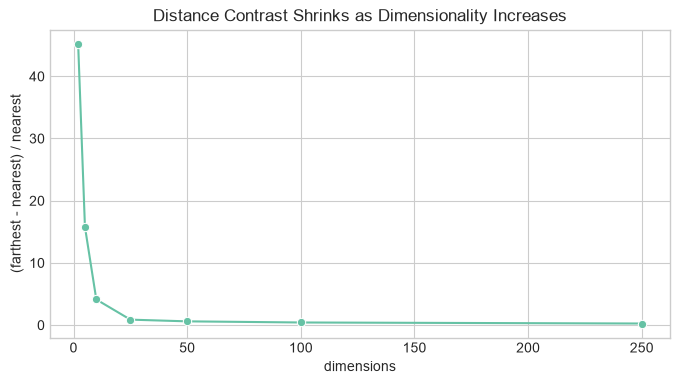

In [3]:
rng = np.random.RandomState(RANDOM_STATE)
dimensions = [2, 5, 10, 25, 50, 100, 250]
rows = []

for dim in dimensions:
    points = rng.uniform(0, 1, size=(700, dim))
    anchor = points[0]
    distances = np.linalg.norm(points[1:] - anchor, axis=1)
    rows.append({
        'dimensions': dim,
        'nearest_distance': distances.min(),
        'farthest_distance': distances.max(),
        'mean_distance': distances.mean(),
        'relative_spread': (distances.max() - distances.min()) / distances.min(),
    })

distance_df = pd.DataFrame(rows)
display(distance_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=distance_df, x='dimensions', y='relative_spread', marker='o', ax=ax)
ax.set_title('Distance Contrast Shrinks as Dimensionality Increases')
ax.set_ylabel('(farthest - nearest) / nearest')
plt.show()

**Observation.** The relative distance spread shrinks as dimensionality grows. This is why dimensionality reduction can help: it tries to keep the useful structure while removing noisy or redundant axes.

## 2. PCA Geometric Intuition

PCA rotates the feature space toward directions of maximum variance. The first principal component captures the strongest linear direction; the second captures the strongest remaining orthogonal direction.

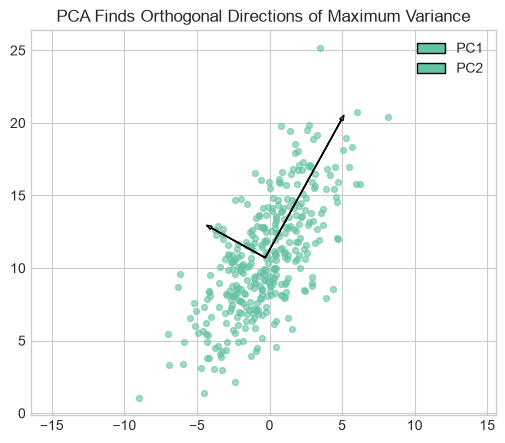

In [4]:
blob_X, _ = make_blobs(n_samples=350, centers=1, n_features=2, cluster_std=[2.5], random_state=RANDOM_STATE)
rotation = np.array([[1.0, 0.75], [0.25, 1.4]])
blob_X = blob_X @ rotation
pca_geo = PCACustom(n_components=2).fit(blob_X)
center = pca_geo.mean_

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(blob_X[:, 0], blob_X[:, 1], s=18, alpha=0.6)
for i, (component, variance) in enumerate(zip(pca_geo.components_, pca_geo.explained_variance_)):
    vector = component * np.sqrt(variance) * 2.5
    ax.arrow(center[0], center[1], vector[0], vector[1], width=0.03, head_width=0.25, label=f'PC{i + 1}')
ax.set_title('PCA Finds Orthogonal Directions of Maximum Variance')
ax.axis('equal')
ax.legend()
plt.show()

## 3. Custom PCA on EnergyTypeNet

This section fits the NumPy PCA implementation on the standardized EnergyTypeNet matrix and verifies it against sklearn PCA up to the unavoidable sign ambiguity of eigenvectors.

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.319842,0.319842
1,PC2,0.178969,0.498811
2,PC3,0.167533,0.666344
3,PC4,0.162954,0.829298
4,PC5,0.153880,0.983179
5,PC6,0.016821,1.000000


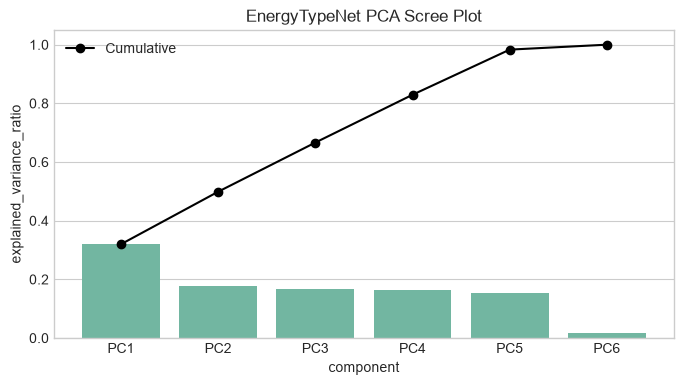

In [5]:
pca_custom = PCACustom(n_components=X_scaled.shape[1]).fit(X_scaled)
pca_sklearn = PCA(n_components=X_scaled.shape[1], random_state=RANDOM_STATE).fit(X_scaled)

np.testing.assert_allclose(
    pca_custom.explained_variance_ratio_,
    pca_sklearn.explained_variance_ratio_,
    atol=1e-6,
)
alignment = np.abs(np.sum(pca_custom.components_ * pca_sklearn.components_, axis=1))
np.testing.assert_allclose(alignment, np.ones_like(alignment), atol=1e-6)

pca_summary = pd.DataFrame({
    'component': [f'PC{i + 1}' for i in range(len(pca_custom.explained_variance_ratio_))],
    'explained_variance_ratio': pca_custom.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca_custom.explained_variance_ratio_),
})
display(pca_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pca_summary, x='component', y='explained_variance_ratio', ax=ax)
ax.plot(pca_summary['component'], pca_summary['cumulative_variance'], color='black', marker='o', label='Cumulative')
ax.set_title('EnergyTypeNet PCA Scree Plot')
ax.legend()
plt.show()

,PC1,PC2
Square Footage,-0.599294,-0.294034
Number of Occupants,-0.298757,-0.012957
Appliances Used,-0.239398,0.669607
Average Temperature,0.020450,-0.681290
Energy Consumption,-0.702722,0.008583
Is Weekend,-0.006583,-0.027798


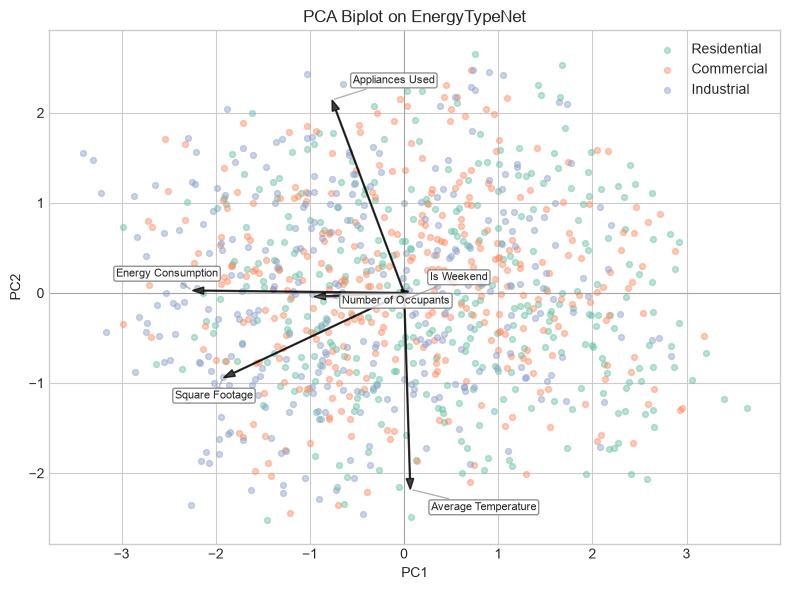

In [7]:
loadings = pd.DataFrame(
    pca_custom.components_[:2].T,
    index=energy_features.columns,
    columns=['PC1', 'PC2'],
)
display(loadings)

Z_pca2 = PCACustom(n_components=2).fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))

for cls_idx, cls_name in enumerate(CLASSES):
    mask = y == cls_idx
    ax.scatter(Z_pca2[mask, 0], Z_pca2[mask, 1],
        s=18, alpha=0.45, label=cls_name)

scale = 3.2
label_offsets = {
    'Square Footage': (-35, -15),
    'Number of Occupants': (20, -5),
    'Appliances Used': (15, 12),
    'Average Temperature': (15, -15),
    'Energy Consumption': (-55, 10),
    'Is Weekend': (20, 15),
}

for feature_name, coords in loadings.iterrows():
    x = coords['PC1'] * scale
    y_arrow = coords['PC2'] * scale

    ax.arrow(0, 0, x, y_arrow, color='black', alpha=0.75, 
        width=0.01, head_width=0.08,
        length_includes_head=True, zorder=4)

    dx, dy = label_offsets.get(feature_name, (10, 10))
    ax.annotate(feature_name, xy=(x, y_arrow), xytext=(dx, dy),
        textcoords='offset points', fontsize=8, 
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.85),
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.6), zorder=5,)

ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Biplot on EnergyTypeNet')
ax.legend()
plt.tight_layout()
plt.show()

**Observation.** The biplot shows that `Energy Consumption` and `Square Footage` contribute strongly to PC1, while `Appliances Used` and `Average Temperature` contribute more strongly to PC2. `Is Weekend` sits close to the origin, which suggests that it contributes very little to the first two principal components.

**Observation.** PCA captures the largest variance directions, but those directions are unsupervised. Strong PCA separation is useful when it appears, but PCA is not trying to maximize class separation.

## 4. PCA 2D and 3D Views

The next plots show how the three building classes appear in two and three principal components.

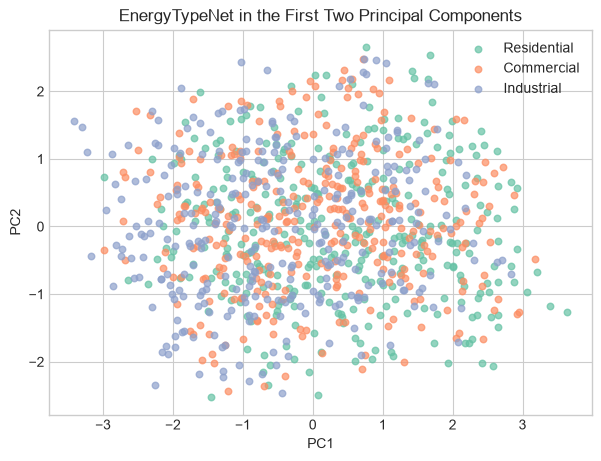

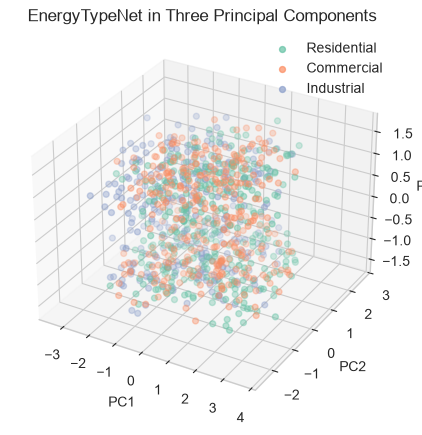

In [8]:
Z_pca3 = PCACustom(n_components=3).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for cls_idx, cls_name in enumerate(CLASSES):
    mask = y == cls_idx
    ax.scatter(Z_pca3[mask, 0], Z_pca3[mask, 1], s=22, alpha=0.7, label=cls_name)
ax.set_title('EnergyTypeNet in the First Two Principal Components')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.show()

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
for cls_idx, cls_name in enumerate(CLASSES):
    mask = y == cls_idx
    ax.scatter(Z_pca3[mask, 0], Z_pca3[mask, 1], Z_pca3[mask, 2], s=18, alpha=0.7, label=cls_name)
ax.set_title('EnergyTypeNet in Three Principal Components')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.show()

## 5. PCA Reconstruction on EnergyTypeNet

Reducing dimensionality loses information. Reconstruction error estimates how much standardized feature information is lost after keeping only the first `k` components.

,components,reconstruction_mse,variance_retained
0,1,6.801578e-01,0.319842
1,2,5.011891e-01,0.498811
2,3,3.336558e-01,0.666344
3,4,1.707017e-01,0.829298
4,5,1.682127e-02,0.983179
5,6,4.828459e-31,1.000000


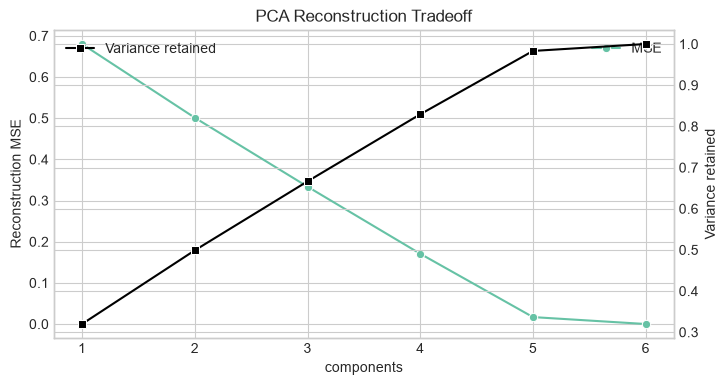

In [9]:
reconstruction_rows = []
for k in range(1, X_scaled.shape[1] + 1):
    model = PCACustom(n_components=k).fit(X_scaled)
    Z = model.transform(X_scaled)
    reconstructed = model.inverse_transform(Z)
    mse = np.mean((X_scaled - reconstructed) ** 2)
    reconstruction_rows.append({
        'components': k,
        'reconstruction_mse': mse,
        'variance_retained': model.explained_variance_ratio_.sum(),
    })

reconstruction_df = pd.DataFrame(reconstruction_rows)
display(reconstruction_df)

fig, ax1 = plt.subplots(figsize=(8, 4))
sns.lineplot(data=reconstruction_df, x='components', y='reconstruction_mse', marker='o', ax=ax1, label='MSE')
ax1.set_ylabel('Reconstruction MSE')
ax2 = ax1.twinx()
sns.lineplot(data=reconstruction_df, x='components', y='variance_retained', marker='s', color='black', ax=ax2, label='Variance retained')
ax2.set_ylabel('Variance retained')
ax1.set_title('PCA Reconstruction Tradeoff')
plt.show()

**Observation.** On EnergyTypeNet, the first two principal components retain about half of the standardized variance, while five components retain almost all of it. This means a 2D PCA plot is useful for visualization, but it is too compressed to preserve the full tabular signal.

## 6. LDA on EnergyTypeNet

LDA is supervised: unlike PCA, it uses class labels and tries to find projections that separate classes. With three building classes, the maximum useful LDA dimension is two.

PCA silhouette: -0.030
LDA silhouette: 0.086


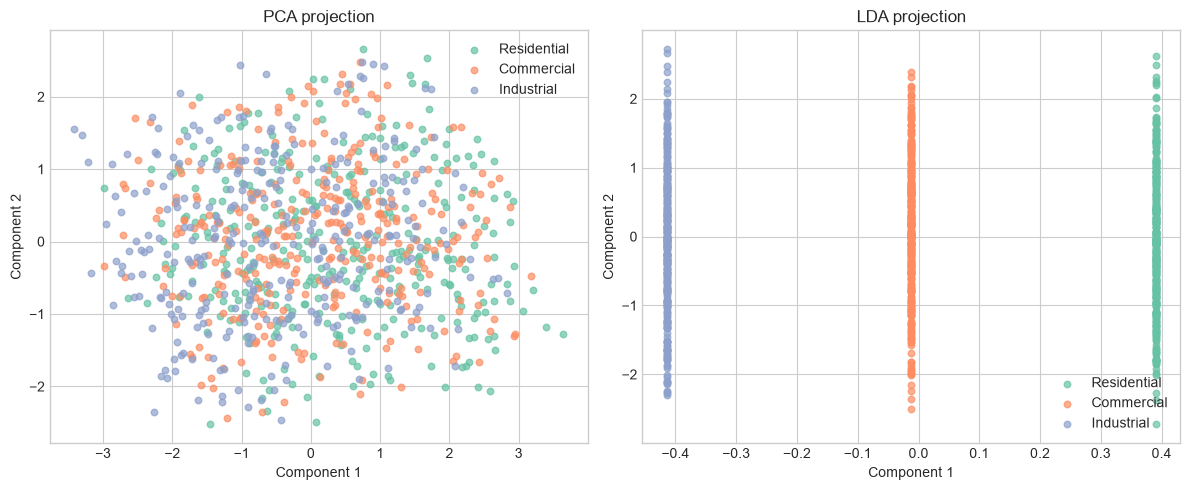

In [10]:
lda_custom = LDACustom(n_components=2).fit(X_scaled, y)
Z_lda = lda_custom.transform(X_scaled)
lda_sklearn = LinearDiscriminantAnalysis(n_components=2, solver='eigen')
Z_lda_sk = lda_sklearn.fit_transform(X_scaled, y)

for col in range(Z_lda.shape[1]):
    scale = np.dot(Z_lda[:, col], Z_lda_sk[:, col]) / np.dot(Z_lda[:, col], Z_lda[:, col])
    np.testing.assert_allclose(Z_lda[:, col] * scale, Z_lda_sk[:, col], atol=1e-4)

sil_pca = silhouette_score(Z_pca2, y)
sil_lda = silhouette_score(Z_lda, y)
print(f'PCA silhouette: {sil_pca:.3f}')
print(f'LDA silhouette: {sil_lda:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, Z, title in [(axes[0], Z_pca2, 'PCA projection'), (axes[1], Z_lda, 'LDA projection')]:
    for cls_idx, cls_name in enumerate(CLASSES):
        mask = y == cls_idx
        ax.scatter(Z[mask, 0], Z[mask, 1], s=22, alpha=0.7, label=cls_name)
    ax.set_title(title)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend()
plt.tight_layout()
plt.show()

**Observation.** LDA gives a better supervised class-separation view than PCA, but the silhouette values are still modest. That supports the larger project finding: the building classes overlap in the available feature space.

**Observation.** LDA usually improves class separation over PCA because it uses the target labels. PCA is best for variance and compression; LDA is best when the goal is supervised separation.

## 7. t-SNE Visualizations

`t-SNE` is used only for visualization. It can reveal local neighborhoods, but distances between far-apart clusters should not be overinterpreted.

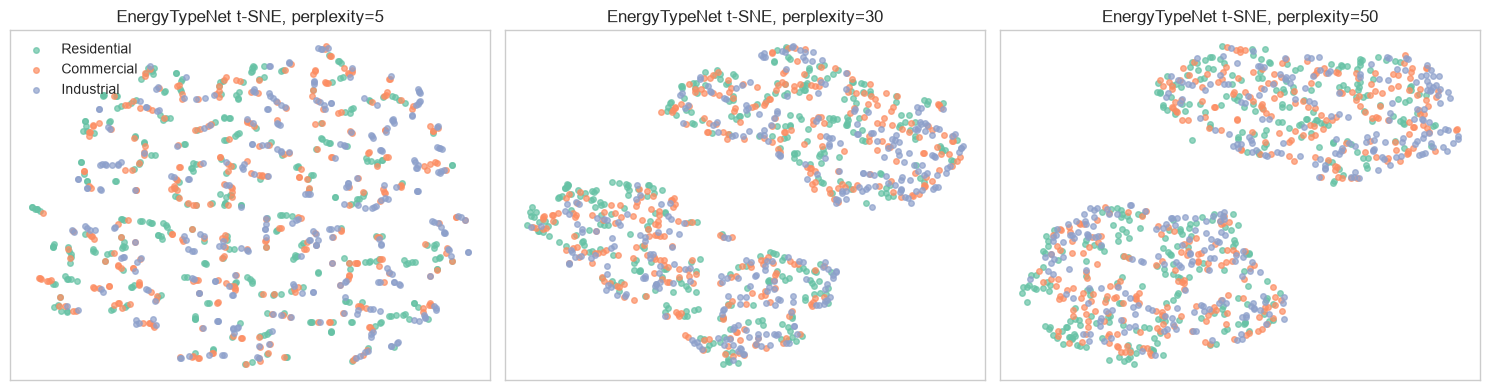

In [11]:
def make_tsne(perplexity):
    kwargs = dict(
        n_components=2,
        perplexity=perplexity,
        init='pca',
        learning_rate='auto',
        random_state=RANDOM_STATE,
    )
    try:
        return TSNE(max_iter=500, **kwargs)
    except TypeError:
        return TSNE(n_iter=500, **kwargs)

perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(15, 4))
for ax, perplexity in zip(axes, perplexities):
    Z_tsne = make_tsne(perplexity).fit_transform(X_scaled)
    for cls_idx, cls_name in enumerate(CLASSES):
        mask = y == cls_idx
        ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1], s=16, alpha=0.7, label=cls_name)
    ax.set_title(f'EnergyTypeNet t-SNE, perplexity={perplexity}')
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].legend()
plt.tight_layout()
plt.show()

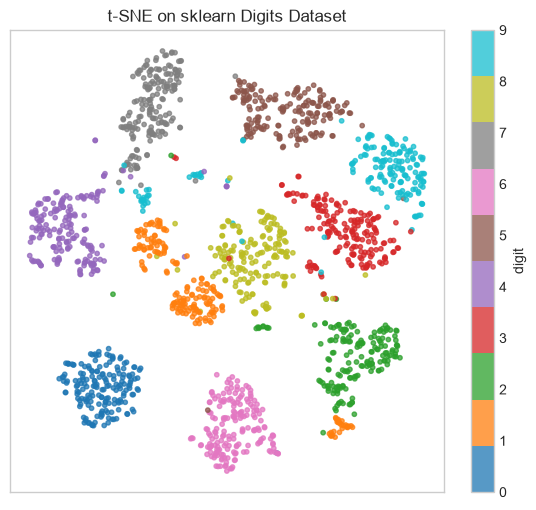

In [12]:
digits = load_digits()
digits_X = StandardScaler().fit_transform(digits.data)
digits_y = digits.target
Z_digits = make_tsne(30).fit_transform(digits_X)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(Z_digits[:, 0], Z_digits[:, 1], c=digits_y, cmap='tab10', s=10, alpha=0.75)
ax.set_title('t-SNE on sklearn Digits Dataset')
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(scatter, ax=ax, label='digit')
plt.show()

## 8. Kernel PCA

Kernel PCA can uncover nonlinear structure by applying PCA in an implicit feature space. I use `make_circles` only because it is the standard clean geometry for showing this effect.

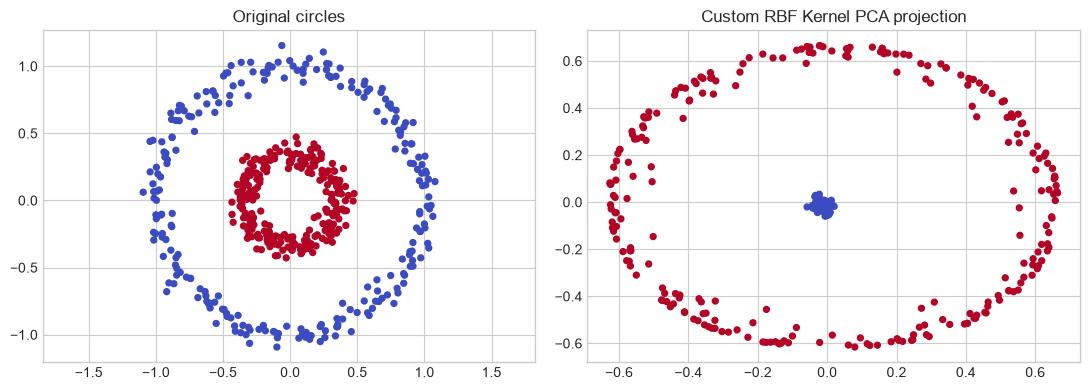

In [13]:
circle_X, circle_y = make_circles(n_samples=500, factor=0.35, noise=0.05, random_state=RANDOM_STATE)
kpca_custom = KernelPCACustom(n_components=2, kernel='rbf', gamma=10.0)
Z_kpca_custom = kpca_custom.fit_transform(circle_X)
kpca_sklearn = KernelPCA(n_components=2, kernel='rbf', gamma=10.0)
Z_kpca_sklearn = kpca_sklearn.fit_transform(circle_X)

corr = np.corrcoef(Z_kpca_custom[:, 0], Z_kpca_sklearn[:, 0])[0, 1]
assert abs(corr) > 0.95

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(circle_X[:, 0], circle_X[:, 1], c=circle_y, cmap='coolwarm', s=18)
axes[0].set_title('Original circles')
axes[0].axis('equal')
axes[1].scatter(Z_kpca_custom[:, 0], Z_kpca_custom[:, 1], c=circle_y, cmap='coolwarm', s=18)
axes[1].set_title('Custom RBF Kernel PCA projection')
plt.tight_layout()
plt.show()

In [14]:
def cv_accuracy_for_features(features, labels):
    clf = LogisticRegression(max_iter=1000)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(clf, features, labels, cv=cv, scoring='accuracy').mean()

raw_acc = cv_accuracy_for_features(X_scaled, y)
pca_acc = cv_accuracy_for_features(PCACustom(n_components=2).fit_transform(X_scaled), y)
kpca_acc = cv_accuracy_for_features(KernelPCACustom(n_components=2, kernel='rbf', gamma=0.5).fit_transform(X_scaled), y)

kernel_summary = pd.DataFrame([
    {'representation': 'Raw standardized features', 'cv_accuracy': raw_acc},
    {'representation': 'PCA 2D', 'cv_accuracy': pca_acc},
    {'representation': 'RBF Kernel PCA 2D', 'cv_accuracy': kpca_acc},
])
display(kernel_summary)

,representation,cv_accuracy
0,Raw standardized features,1.000
1,PCA 2D,0.408
2,RBF Kernel PCA 2D,0.392


## 9. Optional UMAP

UMAP is optional because it is not part of the core requirements and may not be installed in every environment. The notebook skips this section gracefully when `umap-learn` is unavailable.

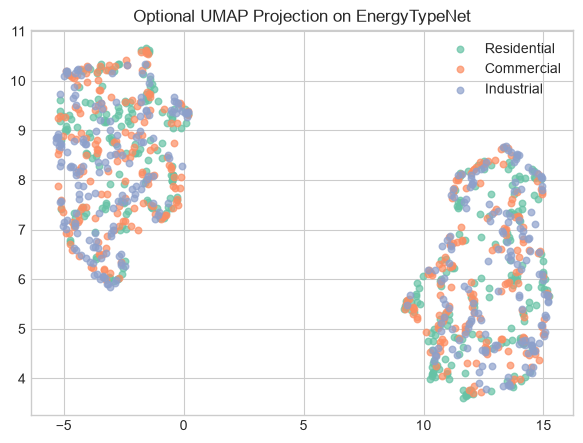

In [16]:
try:
    import umap

    Z_umap = umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
    fig, ax = plt.subplots(figsize=(7, 5))
    for cls_idx, cls_name in enumerate(CLASSES):
        mask = y == cls_idx
        ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1], s=22, alpha=0.7, label=cls_name)
    ax.set_title('Optional UMAP Projection on EnergyTypeNet')
    ax.legend()
    plt.show()
except ImportError:
    print('UMAP is not installed. Skipping optional UMAP section.')

**Observation.** UMAP provides another nonlinear 2D view of EnergyTypeNet. Like t-SNE, it is useful for visual inspection, but it should not replace the downstream accuracy comparison because visual clusters can look cleaner than the actual predictive signal.

## 10. Downstream Impact Study

The final experiment compares whether dimensionality reduction helps or hurts a Logistic Regression classifier. This is the practical test: a pretty 2D plot is not enough if it damages predictive performance.

,representation,n_features,cv_accuracy_mean,cv_accuracy_std,fit_time_seconds
0,Raw features,6,1.000,0.000000,0.100960
3,LDA 2D,2,1.000,0.000000,0.049550
1,PCA 2D,2,0.408,0.027857,0.025236
2,PCA 3D,3,0.407,0.029086,0.023633
4,Kernel PCA 2D,2,0.392,0.033705,0.055137


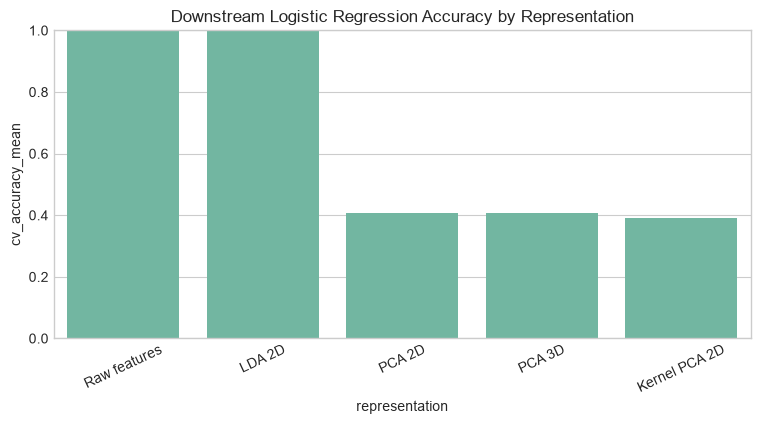

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
representations = {
    'Raw features': X_scaled,
    'PCA 2D': PCACustom(n_components=2).fit_transform(X_scaled),
    'PCA 3D': PCACustom(n_components=3).fit_transform(X_scaled),
    'LDA 2D': LDACustom(n_components=2).fit_transform(X_scaled, y),
    'Kernel PCA 2D': KernelPCACustom(n_components=2, kernel='rbf', gamma=0.5).fit_transform(X_scaled),
}

impact_rows = []
for name, features in representations.items():
    start = time.perf_counter()
    scores = cross_val_score(
        LogisticRegression(max_iter=1000),
        features,
        y,
        cv=cv,
        scoring='accuracy',
    )
    elapsed = time.perf_counter() - start
    impact_rows.append({
        'representation': name,
        'n_features': features.shape[1],
        'cv_accuracy_mean': scores.mean(),
        'cv_accuracy_std': scores.std(),
        'fit_time_seconds': elapsed,
    })

impact_df = pd.DataFrame(impact_rows).sort_values('cv_accuracy_mean', ascending=False)
display(impact_df)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=impact_df, x='representation', y='cv_accuracy_mean', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Downstream Logistic Regression Accuracy by Representation')
ax.tick_params(axis='x', rotation=25)
plt.show()

**Observation.** Raw standardized features and LDA preserve the strongest classification signal, while 2D PCA and 2D Kernel PCA lose substantial predictive information. This is the important practical lesson: dimensionality reduction should be judged by downstream performance, not only by visual appeal.

## 11. Summary

Dimensionality reduction is useful when it is tied to a clear purpose: visualization, compression, denoising or supervised class separation. EnergyTypeNet shows the tradeoff directly: PCA is strong for understanding variance, LDA is stronger for supervised separation, and Kernel PCA can help when nonlinear geometry matters.

In [18]:
summary_table = pd.DataFrame([
    {
        'method': 'PCA',
        'dataset': 'EnergyTypeNet',
        'supervised': 'No',
        'best_use': 'Variance explanation, compression, 2D/3D visualization',
        'main_caution': 'Does not use class labels',
    },
    {
        'method': 'LDA',
        'dataset': 'EnergyTypeNet',
        'supervised': 'Yes',
        'best_use': 'Class-separating projection',
        'main_caution': 'Limited to classes - 1 components',
    },
    {
        'method': 't-SNE',
        'dataset': 'EnergyTypeNet + sklearn digits',
        'supervised': 'No',
        'best_use': 'Local-neighborhood visualization',
        'main_caution': 'Not a predictive feature extractor by default',
    },
    {
        'method': 'Kernel PCA',
        'dataset': 'make_circles + EnergyTypeNet',
        'supervised': 'No',
        'best_use': 'Nonlinear structure discovery',
        'main_caution': 'Kernel and gamma choices matter',
    },
])

display(summary_table)
print('Key takeaway: use dimensionality reduction only when the reduced representation preserves the structure needed for the task.')

,method,dataset,supervised,best_use,main_caution
0,PCA,EnergyTypeNet,No,"Variance explanation, compression, 2D/3D visua...",Does not use class labels
1,LDA,EnergyTypeNet,Yes,Class-separating projection,Limited to classes - 1 components
2,t-SNE,EnergyTypeNet + sklearn digits,No,Local-neighborhood visualization,Not a predictive feature extractor by default
3,Kernel PCA,make_circles + EnergyTypeNet,No,Nonlinear structure discovery,Kernel and gamma choices matter


Key takeaway: use dimensionality reduction only when the reduced representation preserves the structure needed for the task.
